# EPRV 6: Sun-as-a-Star Splinter Part I

## Tutorial: Download HARPS-N solar data from DACE

This tutorial shows how to download HARPS-N solar data using the DACE Python API. To install the DACE API:

`pip install dace_query`

Let's start! First, import some needed packages.

In [5]:
from   astropy.io          import fits
from   astropy.time        import Time
from   dace_query.sun      import Sun
from   glob                import glob
import matplotlib.cm       as     cm
from   matplotlib.colors   import LinearSegmentedColormap, Normalize
import matplotlib.pyplot   as     plt
import numpy               as     np
import os

Specify and create the output directory.

In [6]:
output_directory = 'S1D_spectra/sun_harpsN/'
os.makedirs(output_directory, exist_ok=True)

In [7]:
# Filter: Barycentric Julian Date (BJD)
obj_date_bjd_min = Time('2018-07-01T00:00:00').jd - 2400000
obj_date_bjd_max = Time('2019-02-01T00:00:00').jd - 2400000

# Filter: Quality flag
spectro_analysis_qualflag_min = 0.95
spectro_analysis_qualflag_max = 1.00

# Filter dictionary
filters = {
    'obj_date_bjd': {'min': obj_date_bjd_min, 'max': obj_date_bjd_max},
    'spectro_analysis_qualflag': {
        'min': spectro_analysis_qualflag_min,
        'max': spectro_analysis_qualflag_max,
    },
}

# Query all matching observations as a pandas DataFrame
sun_df = Sun.query_database(filters=filters, sort={'obj_date_bjd': 'asc'}, output_format='pandas')

# Keep only one observation per night
one_per_night = (
    sun_df.sort_values('obj_date_bjd')
    .drop_duplicates(subset='date_night', keep='first')
    .reset_index(drop=True)
)

display(one_per_night[['date_night', 'obj_date_bjd', 'file_rootpath']])
print(f'Selected {len(one_per_night)} observations for download.')

# Download one S1D spectrum per night
for _, row in one_per_night.iterrows():
    night = str(row['date_night'])
    night_directory = os.path.join(output_directory, night)
    os.makedirs(night_directory, exist_ok=True)

    Sun.download(
        's1d',
        filters={'file_rootpath': {'contains': [os.path.basename(str(row['file_rootpath']))]}},
        output_directory=night_directory,
    )

,date_night,obj_date_bjd,file_rootpath
0,2018-06-30,58300.847575,harpn/DRS-3.0.1/reduced/2018-06-30/r.HARPN.201...
1,2018-07-01,58300.873671,harpn/DRS-3.0.1/reduced/2018-07-01/r.HARPN.201...
2,2018-07-02,58301.980250,harpn/DRS-3.0.1/reduced/2018-07-02/r.HARPN.201...
3,2018-07-03,58302.874495,harpn/DRS-3.0.1/reduced/2018-07-03/r.HARPN.201...
4,2018-07-04,58303.890734,harpn/DRS-3.0.1/reduced/2018-07-04/r.HARPN.201...
...,...,...,...
163,2019-01-26,58509.924213,harpn/DRS-3.0.1/reduced/2019-01-26/r.HARPN.201...
164,2019-01-27,58510.934418,harpn/DRS-3.0.1/reduced/2019-01-27/r.HARPN.201...
165,2019-01-28,58511.969524,harpn/DRS-3.0.1/reduced/2019-01-28/r.HARPN.201...
166,2019-01-29,58512.961874,harpn/DRS-3.0.1/reduced/2019-01-29/r.HARPN.201...


Selected 168 observations for download.


2026-05-19 16:01:17,458 - INFO - Downloading file on location : S1D_spectra/sun_harpsN/2018-06-30/r.HARPN.2018-07-01T08-25-15.495_S1D_A.fits


 Download : 6 MB

2026-05-19 16:01:18,448 - INFO - File downloaded on location : S1D_spectra/sun_harpsN/2018-06-30/r.HARPN.2018-07-01T08-25-15.495_S1D_A.fits


...

 Download : 7 MB
Download done


2026-05-19 16:04:58,579 - INFO - Downloading file on location : S1D_spectra/sun_harpsN/2019-01-31/r.HARPN.2019-01-31T09-56-15.040_S1D_A.fits


 Download : 6 MB

2026-05-19 16:04:59,551 - INFO - File downloaded on location : S1D_spectra/sun_harpsN/2019-01-31/r.HARPN.2019-01-31T09-56-15.040_S1D_A.fits


 Download : 7 MB
Download done


Next, loop over the downloaded FITS files and extract the S1D spectra together with a few header quantities such as BJD and RV.

In [8]:
# Files
files = sorted(glob(output_directory + '**/*.fits', recursive=True))
Nfile = len(files)

def get_header_value(header, keys):
    for key in keys:
        if key in header:
            return header[key]
    return np.nan

# Get wavelength grid from first file
hdul = fits.open(files[0])
wave_val = hdul[1].data['wavelength']
Nwave = len(wave_val)
hdul.close()

# Empty arrays for spectral and RV variables
flux_val = np.empty((Nfile, Nwave))
flux_err = np.empty((Nfile, Nwave))
time_val = np.empty(Nfile)
vrad_val = np.empty(Nfile)
vrad_err = np.empty(Nfile)

# Loop files
for i, file in enumerate(files):

    # Open FITS file
    hdul = fits.open(file)
    spectrum = hdul[1].data

    # Extract S1D spectrum
    flux_val[i] = spectrum['flux']
    flux_err[i] = spectrum['error']

    # Extract RV variables
    header = hdul[0].header
    time_val[i] = get_header_value(header, ['HIERARCH TNG QC BJD', 'TNG QC BJD', 'HIERARCH ESO QC BJD', 'ESO QC BJD'])
    vrad_val[i] = get_header_value(header, ['HIERARCH TNG QC CCF RV', 'TNG QC CCF RV', 'HIERARCH ESO QC CCF RV', 'ESO QC CCF RV'])
    vrad_err[i] = get_header_value(header, ['HIERARCH TNG QC CCF RV ERROR', 'TNG QC CCF RV ERROR', 'HIERARCH ESO QC CCF RV ERROR', 'ESO QC CCF RV ERROR'])

    # Close FITS file
    hdul.close()

Finally, plot the extracted data.

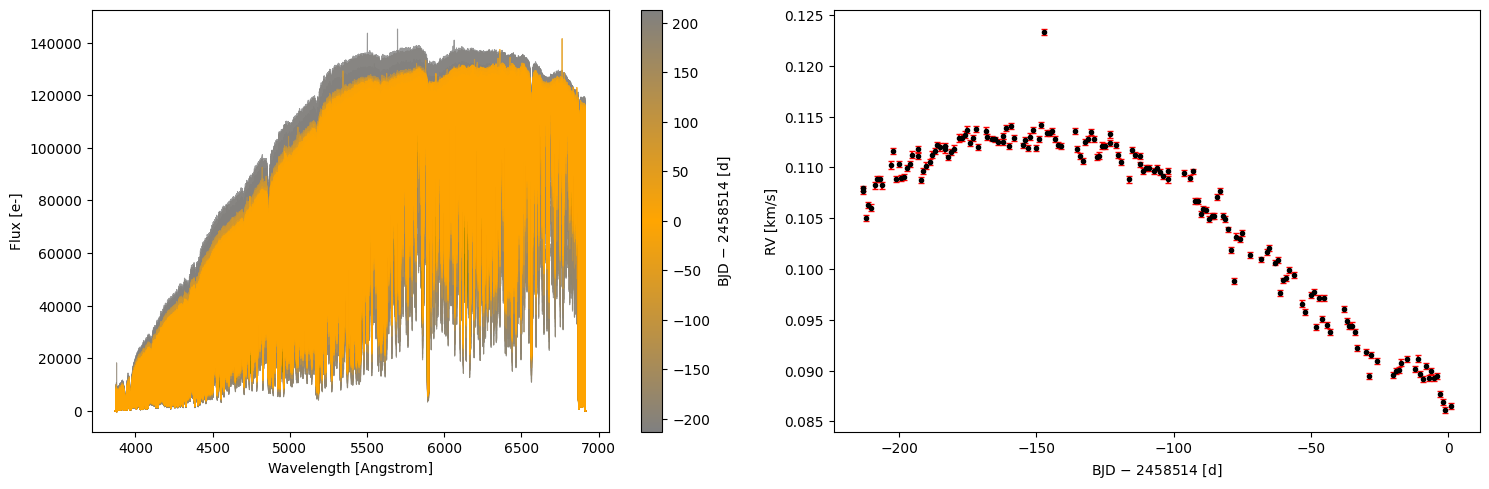

In [9]:
# Normalization
cval = time_val - int(np.nanmax(time_val))
vmax = np.nanmax(np.abs(cval))
norm = Normalize(vmin=-vmax, vmax=vmax)

# Color map
values = [0.0, 0.5, 1.0]
colors = ['grey', 'orange', 'grey']
cmap = LinearSegmentedColormap.from_list('rg', list(zip(values, colors)), N=256)

# Colors
cmsm = cm.ScalarMappable(norm=norm, cmap=cmap)
color = cmsm.to_rgba(cval)

# Figure
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# S1D spectral time series
ax = axs[0]
for i in range(Nfile):
    ax.plot(wave_val, flux_val[i], color=color[i], lw=0.8, alpha=0.8)
ax.set_xlabel('Wavelength [Angstrom]')
ax.set_ylabel('Flux [e-]')
cb = plt.colorbar(cmsm, ax=ax)
cb.set_label(f'BJD $-$ {int(np.nanmax(time_val))} [d]')

# RV time series
ax = axs[1]
ax.errorbar(time_val - int(np.nanmax(time_val)), vrad_val, vrad_err, fmt='.', color='k', ecolor='r', capsize=2)
ax.set_xlabel(f'BJD $-$ {int(np.nanmax(time_val))} [d]')
ax.set_ylabel('RV [km/s]')

# Show
plt.tight_layout()
plt.show()